# SinLlama Sinhala Corpus Analysis for Font-Image / Pixel-Language Research

This notebook analyzes `polyglots/MADLAD_CulturaX_cleaned` without requiring the full dataset to fit in RAM.

It calculates:

- Dataset row length
- Word-count distribution
- Unicode code-point distribution
- Sinhala grapheme-cluster distribution
- Sinhala Unicode character frequencies
- Rendered font width
- Wrapped image-line distribution
- Font glyph coverage

> Important: the dataset's `text` row is treated as the analysis unit. Some rows may contain more than one linguistic sentence. Keep this distinction clear in the research report.


In [1]:
# Install only the additional packages needed
%pip install -q datasets duckdb regex fonttools

# Install Sinhala font and text-rendering support
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core libraqm0

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 1. Configuration

Start with `MAX_ROWS = 200_000` to test the workflow.  
After checking the outputs, change it to `None` to scan the complete dataset.

For a complete scan, keep `SHUFFLE_STREAM = False`. Shuffling a very large streamed dataset is unnecessary for exact corpus-level statistics.


In [2]:
from pathlib import Path
import os
import math
import random
import hashlib
import heapq
import unicodedata
from collections import Counter

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import regex
from datasets import load_dataset
from tqdm.auto import tqdm

# ---------------- USER SETTINGS ----------------
DATASET_ID = "polyglots/MADLAD_CulturaX_cleaned"
SPLIT = "train"

# Use 200_000 for a first experiment. Use None for the full corpus.
MAX_ROWS = None

# For a quick random-like sample, turn this on.
# Keep it False for a complete sequential scan.
SHUFFLE_STREAM = False
SHUFFLE_BUFFER = 20_000
RANDOM_SEED = 42

# Disk-writing settings
CHUNK_SIZE = 25_000
PIXEL_SAMPLE_SIZE = 10_000
LONGEST_EXAMPLES_TO_KEEP = 20

# Font-image settings
FONT_SIZE = 32
CANVAS_WIDTH = 1024
HORIZONTAL_MARGIN = 32
VERTICAL_MARGIN = 24
LINE_SPACING_MULTIPLIER = 1.35

OUTPUT_DIR = Path("/content/sinllama_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PARQUET = OUTPUT_DIR / "row_metrics.parquet"
CHAR_FREQ_CSV = OUTPUT_DIR / "character_frequency.csv"
LONGEST_CSV = OUTPUT_DIR / "longest_examples.csv"
PIXEL_METRICS_CSV = OUTPUT_DIR / "pixel_metrics_sample.csv"

# Remove an old metrics file so rerunning does not mix results.
if METRICS_PARQUET.exists():
    METRICS_PARQUET.unlink()

print("Output directory:", OUTPUT_DIR)


Output directory: /content/sinllama_analysis


## 2. Load the dataset in streaming mode

Streaming reads examples progressively instead of loading the complete corpus into memory.


In [3]:
dataset = load_dataset(
    DATASET_ID,
    split=SPLIT,
    streaming=True,
)

if SHUFFLE_STREAM:
    dataset = dataset.shuffle(
        seed=RANDOM_SEED,
        buffer_size=SHUFFLE_BUFFER,
    )

first_example = next(iter(dataset))
print("Columns:", list(first_example.keys()))
print("Example:")
print(first_example)


Columns: ['text', 'lang', 'src']
Example:
{'text': 'ආණ්ඩුව පටන් ගත් වහා\u2009ම ආණ්ඩුවෙන් බේරීමට පොලිස් පරීක්ෂක නිශාන්ත සිල්වා රට හැර ගියේ\u2009ය.', 'lang': 'si', 'src': 'CulturaX'}


## 3. Define text metrics

### Why grapheme clusters matter

A visible Sinhala unit can contain multiple Unicode code points, such as a base letter plus vowel signs or combining marks. Therefore:

- `codepoint_count` measures Python/Unicode string length.
- `grapheme_count` is a closer approximation to user-perceived visible character units.
- `pixel_width` later measures the actual width produced by the chosen font and font size.

The original text is not replaced. NFC normalization is used only for consistent analysis, and the notebook records whether normalization changed the row.


In [4]:
GRAPHEME_RE = regex.compile(r"\X")
NONSPACE_RE = regex.compile(r"\S+")
SINHALA_RE = regex.compile(r"[\u0D80-\u0DFF]")

def safe_preview(text, limit=300):
    text = " ".join((text or "").split())
    return text[:limit]

def calculate_row_metrics(text, lang=None, src=None):
    raw = text if isinstance(text, str) else ""
    nfc = unicodedata.normalize("NFC", raw)

    words = NONSPACE_RE.findall(nfc)
    graphemes = GRAPHEME_RE.findall(nfc)
    nonspace_chars = [ch for ch in nfc if not ch.isspace()]

    word_count = len(words)
    raw_codepoint_count = len(raw)
    codepoint_count = len(nfc)
    grapheme_count = len(graphemes)
    utf8_byte_count = len(nfc.encode("utf-8"))

    sinhala_codepoint_count = sum(
        0x0D80 <= ord(ch) <= 0x0DFF for ch in nfc
    )
    latin_letter_count = sum(
        ("LATIN" in unicodedata.name(ch, "")) and ch.isalpha()
        for ch in nfc
    )
    digit_count = sum(ch.isdigit() for ch in nfc)
    punctuation_count = sum(
        unicodedata.category(ch).startswith("P") for ch in nfc
    )
    mark_count = sum(
        unicodedata.category(ch).startswith("M") for ch in nfc
    )
    control_count = sum(
        unicodedata.category(ch).startswith("C") for ch in nfc
    )
    whitespace_count = sum(ch.isspace() for ch in nfc)

    nonspace_count = len(nonspace_chars)
    sinhala_ratio_nonspace = (
        sinhala_codepoint_count / nonspace_count if nonspace_count else 0.0
    )

    word_lengths = [len(word) for word in words]
    avg_word_codepoints = (
        float(np.mean(word_lengths)) if word_lengths else 0.0
    )
    max_word_codepoints = max(word_lengths, default=0)

    normalized_hash16 = hashlib.blake2b(
        nfc.encode("utf-8"), digest_size=8
    ).hexdigest()

    return {
        "word_count": word_count,
        "raw_codepoint_count": raw_codepoint_count,
        "codepoint_count": codepoint_count,
        "grapheme_count": grapheme_count,
        "utf8_byte_count": utf8_byte_count,
        "line_count": (nfc.count("\\n") + 1) if nfc else 0,
        "whitespace_count": whitespace_count,
        "sinhala_codepoint_count": sinhala_codepoint_count,
        "sinhala_ratio_nonspace": sinhala_ratio_nonspace,
        "latin_letter_count": latin_letter_count,
        "digit_count": digit_count,
        "punctuation_count": punctuation_count,
        "combining_mark_count": mark_count,
        "control_count": control_count,
        "avg_word_codepoints": avg_word_codepoints,
        "max_word_codepoints": max_word_codepoints,
        "normalization_changed": raw != nfc,
        "hash16": normalized_hash16,
        "lang": str(lang or ""),
        "src": str(src or ""),
    }


## 4. Scan the corpus and write metrics to Parquet

The notebook writes batches to disk, so it does not keep millions of metric rows in RAM.

It also keeps:

- a reservoir sample of text rows for pixel/font analysis
- a corpus-wide character-frequency counter
- a small list of the longest rows for manual inspection


In [5]:
rng = random.Random(RANDOM_SEED)
pixel_text_sample = []
character_counter = Counter()
source_counter = Counter()
language_counter = Counter()
longest_heap = []

buffer = []
writer = None
rows_seen = 0

def update_reservoir(sample, item, seen_count, target_size, rng):
    if len(sample) < target_size:
        sample.append(item)
    else:
        replacement_index = rng.randint(1, seen_count)
        if replacement_index <= target_size:
            sample[replacement_index - 1] = item

def flush_buffer(records, writer):
    if not records:
        return writer

    table = pa.Table.from_pylist(records)

    if writer is None:
        writer = pq.ParquetWriter(
            METRICS_PARQUET,
            table.schema,
            compression="zstd",
        )

    writer.write_table(table)
    records.clear()
    return writer

# Re-create the stream because the preview cell consumed a separate iterator.
dataset = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
if SHUFFLE_STREAM:
    dataset = dataset.shuffle(
        seed=RANDOM_SEED,
        buffer_size=SHUFFLE_BUFFER,
    )

try:
    for example in tqdm(dataset, total=MAX_ROWS):
        if MAX_ROWS is not None and rows_seen >= MAX_ROWS:
            break

        text = example.get("text", "")
        lang = example.get("lang", "")
        src = example.get("src", "")

        metrics = calculate_row_metrics(text, lang=lang, src=src)
        buffer.append(metrics)

        normalized_text = unicodedata.normalize(
            "NFC", text if isinstance(text, str) else ""
        )
        character_counter.update(normalized_text)
        source_counter[str(src)] += 1
        language_counter[str(lang)] += 1

        rows_seen += 1

        # Uniform reservoir sample across the scanned stream.
        update_reservoir(
            pixel_text_sample,
            {
                "text": normalized_text,
                "word_count": metrics["word_count"],
                "grapheme_count": metrics["grapheme_count"],
                "codepoint_count": metrics["codepoint_count"],
                "src": str(src),
            },
            rows_seen,
            PIXEL_SAMPLE_SIZE,
            rng,
        )

        # Keep longest examples by grapheme count.
        heap_item = (
            metrics["grapheme_count"],
            rows_seen,
            metrics["word_count"],
            safe_preview(normalized_text),
            str(src),
        )
        if len(longest_heap) < LONGEST_EXAMPLES_TO_KEEP:
            heapq.heappush(longest_heap, heap_item)
        elif heap_item[0] > longest_heap[0][0]:
            heapq.heapreplace(longest_heap, heap_item)

        if len(buffer) >= CHUNK_SIZE:
            writer = flush_buffer(buffer, writer)

    writer = flush_buffer(buffer, writer)

finally:
    if writer is not None:
        writer.close()

print(f"Scanned rows: {rows_seen:,}")
print("Metrics file:", METRICS_PARQUET)
print("Metrics file size (MB):", round(METRICS_PARQUET.stat().st_size / 1e6, 2))


0it [00:00, ?it/s]

Scanned rows: 10,730,154
Metrics file: /content/sinllama_analysis/row_metrics.parquet
Metrics file size (MB): 266.41


## 5. Save character frequencies and longest examples


In [6]:
char_rows = []
for character, count in character_counter.most_common():
    char_rows.append({
        "character": character,
        "codepoint": f"U+{ord(character):04X}",
        "unicode_name": unicodedata.name(character, "UNNAMED"),
        "unicode_category": unicodedata.category(character),
        "count": count,
        "is_sinhala_block": 0x0D80 <= ord(character) <= 0x0DFF,
        "is_whitespace": character.isspace(),
    })

char_df = pd.DataFrame(char_rows)
char_df.to_csv(CHAR_FREQ_CSV, index=False, encoding="utf-8-sig")

longest_df = pd.DataFrame(
    sorted(longest_heap, reverse=True),
    columns=[
        "grapheme_count",
        "row_number",
        "word_count",
        "text_preview",
        "src",
    ],
)
longest_df.to_csv(LONGEST_CSV, index=False, encoding="utf-8-sig")

print("Saved:", CHAR_FREQ_CSV)
print("Saved:", LONGEST_CSV)
display(longest_df.head(10))


Saved: /content/sinllama_analysis/character_frequency.csv
Saved: /content/sinllama_analysis/longest_examples.csv


,grapheme_count,row_number,word_count,text_preview,src
0,18050,5526799,2417,"NYCity, Weehawken, බටහිර නිව් යෝර්ක්, වෘත්තීය ...",CulturaX
1,12052,5965114,1661,"Bridgeport, Fairfield, ස්ට්රැට්ෆඩ්, Southport,...",CulturaX
2,11922,4664373,1544,"විල්මින්ග්ටන්, Montchanin, රොක්ලන්ඩ්, Penns ග්...",CulturaX
3,10364,6788638,1386,"බොස්ටන්, කේම්බ්රිජ්, චාල්ස්ටවුන්, සොමර්විල්, ච...",CulturaX
4,10289,4841469,1378,"දේවාරක්ෂාව, නැගෙනහිර ප්රොවිඩන්ස්, Cranston, Ru...",CulturaX
5,10272,1564973,1473,"හන්ටින්ටන්, චෙසපීක්, Proctorville, Ceredo, දකු...",CulturaX
6,7129,2994815,1068,"චිකාගෝ, AMF Ohare, Cicero, ඕක් පාක්හි, Berwyn,...",CulturaX
7,5375,7579304,1123,Air Pollution (1) Capital Flight (1) China (2)...,CulturaX
8,5259,8299668,742,අයර්ලන්තය (Ireland) අයිල් ඔෆ් මෑන් (Isle of Ma...,CulturaX
9,5259,3064753,742,අයර්ලන්තය (Ireland) අයිල් ඔෆ් මෑන් (Isle of Ma...,CulturaX


## 6. Corpus summary with DuckDB

DuckDB reads the Parquet file directly from disk. This allows exact counts and efficient approximate quantiles without loading the complete metrics table into pandas.


In [7]:
con = duckdb.connect()

metric_columns = [
    "word_count",
    "codepoint_count",
    "grapheme_count",
    "utf8_byte_count",
    "sinhala_ratio_nonspace",
    "punctuation_count",
    "latin_letter_count",
]

summary_rows = []

for column in metric_columns:
    result = con.execute(f'''
        SELECT
            COUNT(*) AS n,
            MIN({column}) AS minimum,
            APPROX_QUANTILE({column}, 0.10) AS p10,
            APPROX_QUANTILE({column}, 0.25) AS p25,
            APPROX_QUANTILE({column}, 0.50) AS median,
            APPROX_QUANTILE({column}, 0.75) AS p75,
            APPROX_QUANTILE({column}, 0.90) AS p90,
            APPROX_QUANTILE({column}, 0.95) AS p95,
            APPROX_QUANTILE({column}, 0.99) AS p99,
            MAX({column}) AS maximum,
            AVG({column}) AS mean,
            STDDEV_SAMP({column}) AS standard_deviation
        FROM read_parquet('{METRICS_PARQUET}')
    ''').fetchone()

    summary_rows.append({
        "metric": column,
        "n": result[0],
        "min": result[1],
        "p10": result[2],
        "p25": result[3],
        "median": result[4],
        "p75": result[5],
        "p90": result[6],
        "p95": result[7],
        "p99": result[8],
        "max": result[9],
        "mean": result[10],
        "std": result[11],
    })

summary_df = pd.DataFrame(summary_rows)
SUMMARY_CSV = OUTPUT_DIR / "summary_statistics.csv"
summary_df.to_csv(SUMMARY_CSV, index=False)

normalization_stats = con.execute(f'''
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN normalization_changed THEN 1 ELSE 0 END)
            AS normalization_changed_rows,
        AVG(CASE WHEN normalization_changed THEN 1.0 ELSE 0.0 END)
            AS normalization_changed_fraction,
        SUM(CASE WHEN word_count = 0 THEN 1 ELSE 0 END) AS empty_rows,
        AVG(sinhala_ratio_nonspace) AS mean_sinhala_ratio
    FROM read_parquet('{METRICS_PARQUET}')
''').df()

# Hash-based estimate: an extremely small chance of collision remains because
# only 64 bits of the normalized-text hash are stored.
duplicate_stats = con.execute(f'''
    SELECT
        COUNT(*) AS rows,
        APPROX_COUNT_DISTINCT(hash16) AS approximately_unique_hashes,
        COUNT(*) - APPROX_COUNT_DISTINCT(hash16)
            AS approximately_repeated_rows
    FROM read_parquet('{METRICS_PARQUET}')
''').df()

display(summary_df)
display(normalization_stats)
display(duplicate_stats)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,metric,n,min,p10,p25,median,p75,p90,p95,p99,max,mean,std
0,word_count,10730154,5.000000,8.000000,10.000000,14.000000,22.000000,31.000000,39.000000,59.0,2417.0,17.585658,11.976278
1,codepoint_count,10730154,13.000000,46.000000,60.000000,88.000000,137.000000,202.000000,250.000000,385.0,21316.0,110.641017,79.356316
2,grapheme_count,10730154,10.000000,33.000000,43.000000,63.000000,98.000000,143.000000,177.000000,273.0,18050.0,78.698737,56.495703
3,utf8_byte_count,10730154,21.000000,119.000000,155.000000,232.000000,361.000000,534.000000,662.000000,1016.0,37490.0,290.373216,208.430868
4,sinhala_ratio_nonspace,10730154,0.095462,0.871982,0.935943,0.964284,0.978242,0.986031,0.990045,1.0,1.0,0.939800,0.075516
5,punctuation_count,10730154,0.000000,1.000000,1.000000,1.000000,3.000000,5.000000,6.000000,12.0,1757.0,2.213078,3.081865
6,latin_letter_count,10730154,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,29.0,9056.0,1.413066,7.793953


,total_rows,normalization_changed_rows,normalization_changed_fraction,empty_rows,mean_sinhala_ratio
0,10730154,42447.0,0.003956,0.0,0.9398


,rows,approximately_unique_hashes,approximately_repeated_rows
0,10730154,9715920,1014234


## 7. Source distribution


,source,rows,percentage
0,CulturaX,10730154,100.0


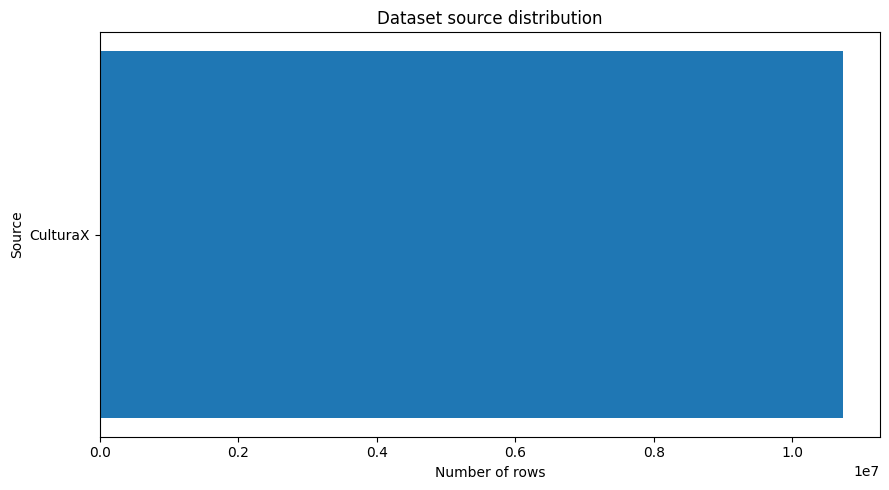

In [8]:
source_df = (
    pd.DataFrame(source_counter.items(), columns=["source", "rows"])
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)
source_df["percentage"] = 100 * source_df["rows"] / source_df["rows"].sum()
source_df.to_csv(OUTPUT_DIR / "source_distribution.csv", index=False)

display(source_df)

plt.figure(figsize=(9, 5))
plot_source = source_df.head(15).sort_values("rows")
plt.barh(plot_source["source"], plot_source["rows"])
plt.xlabel("Number of rows")
plt.ylabel("Source")
plt.title("Dataset source distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "source_distribution.png", dpi=180)
plt.show()


## 8. Distribution charts

The charts are clipped at the 99.5th percentile so that a few extreme rows do not compress the main distribution. The maximum and upper quantiles remain available in `summary_statistics.csv`.


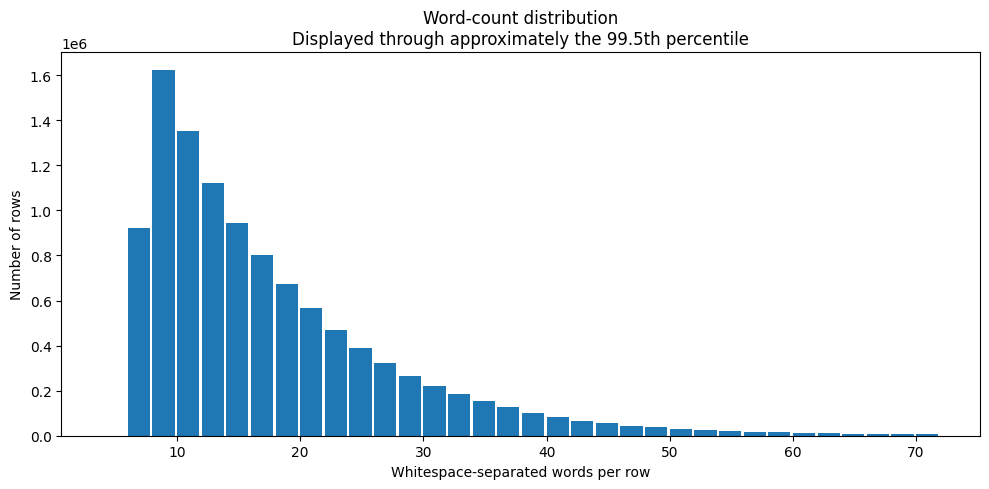

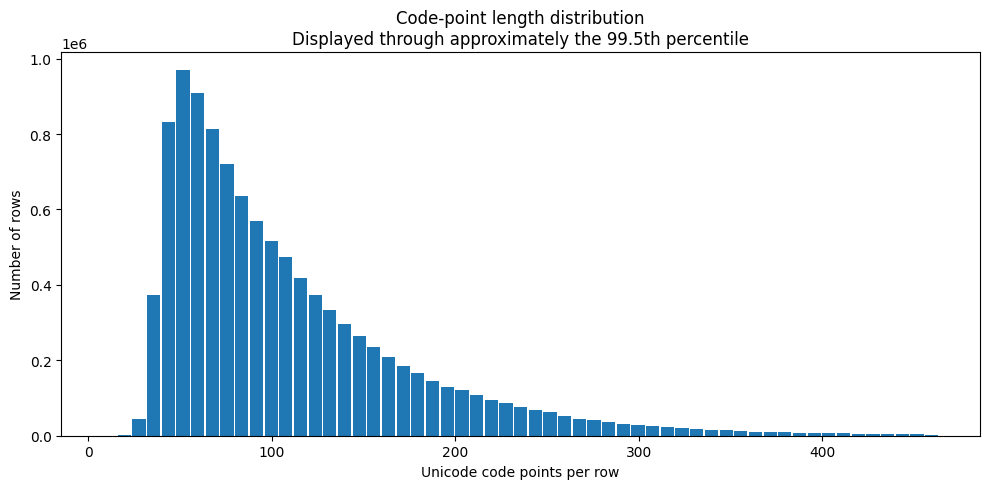

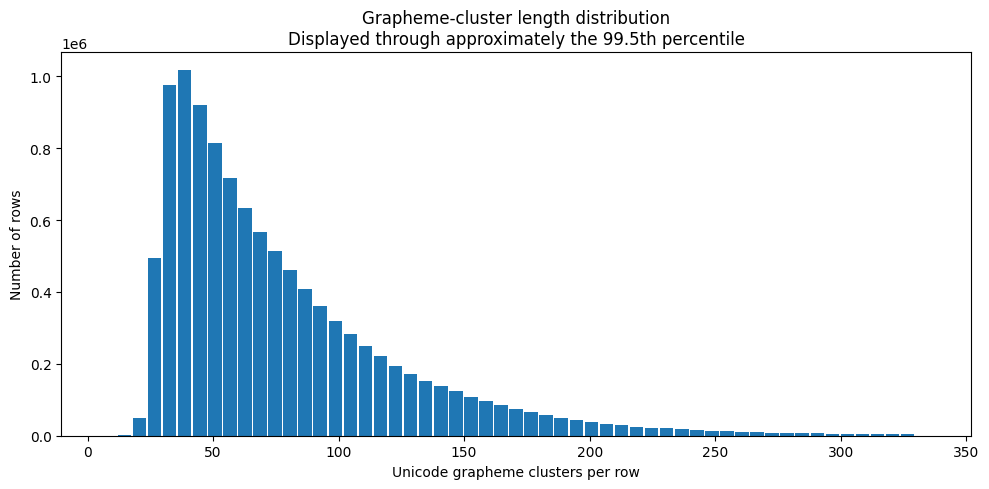

In [9]:
def query_binned_distribution(column, bins=60, upper_quantile=0.995):
    upper = con.execute(f'''
        SELECT APPROX_QUANTILE({column}, {upper_quantile})
        FROM read_parquet('{METRICS_PARQUET}')
    ''').fetchone()[0]

    upper = float(upper or 0)
    bin_width = max(1.0, math.ceil(upper / bins))

    distribution = con.execute(f'''
        SELECT
            FLOOR({column} / {bin_width}) * {bin_width} AS bin_start,
            COUNT(*) AS frequency
        FROM read_parquet('{METRICS_PARQUET}')
        WHERE {column} >= 0 AND {column} <= {upper}
        GROUP BY 1
        ORDER BY 1
    ''').df()

    return distribution, upper, bin_width

def plot_distribution(column, xlabel, title, filename):
    distribution, upper, bin_width = query_binned_distribution(column)

    plt.figure(figsize=(10, 5))
    plt.bar(
        distribution["bin_start"],
        distribution["frequency"],
        width=bin_width * 0.9,
        align="edge",
    )
    plt.xlabel(xlabel)
    plt.ylabel("Number of rows")
    plt.title(f"{title}\nDisplayed through approximately the 99.5th percentile")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

plot_distribution(
    "word_count",
    "Whitespace-separated words per row",
    "Word-count distribution",
    "word_count_distribution.png",
)

plot_distribution(
    "codepoint_count",
    "Unicode code points per row",
    "Code-point length distribution",
    "codepoint_distribution.png",
)

plot_distribution(
    "grapheme_count",
    "Unicode grapheme clusters per row",
    "Grapheme-cluster length distribution",
    "grapheme_distribution.png",
)


## 9. Relationship between word count and visual-unit length

This chart uses a manageable subset from the Parquet file.


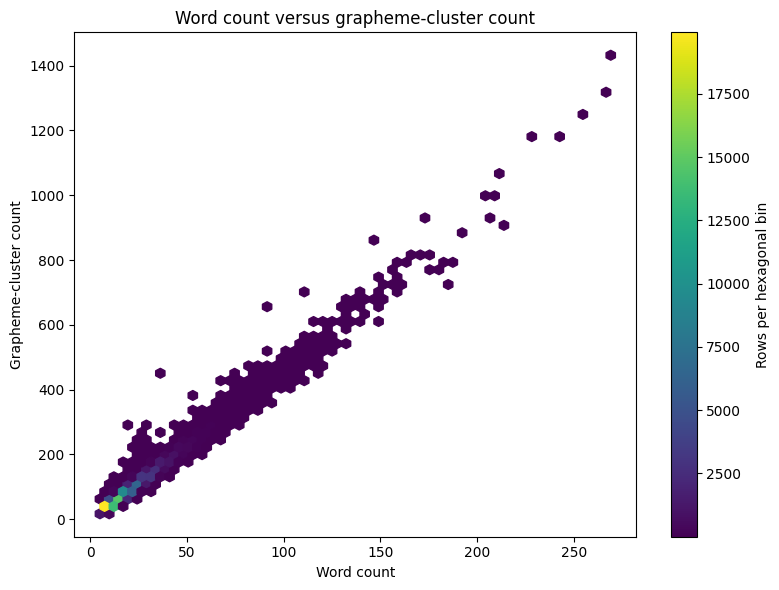

In [10]:
scatter_df = con.execute(f'''
    SELECT
        word_count,
        grapheme_count,
        codepoint_count,
        sinhala_ratio_nonspace
    FROM read_parquet('{METRICS_PARQUET}')
    WHERE word_count > 0
    LIMIT 100000
''').df()

plt.figure(figsize=(8, 6))
plt.hexbin(
    scatter_df["word_count"],
    scatter_df["grapheme_count"],
    gridsize=55,
    mincnt=1,
)
plt.xlabel("Word count")
plt.ylabel("Grapheme-cluster count")
plt.title("Word count versus grapheme-cluster count")
plt.colorbar(label="Rows per hexagonal bin")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "word_vs_grapheme_hexbin.png", dpi=180)
plt.show()


## 10. Most frequent Sinhala characters

Whitespace is excluded. The table includes Unicode code point and Unicode name, which is more reliable than depending on notebook font rendering.


,character,codepoint,unicode_name,unicode_category,count,is_sinhala_block,is_whitespace
1,්,U+0DCA,SINHALA SIGN AL-LAKUNA,Mn,84909803,True,False
2,ි,U+0DD2,SINHALA VOWEL SIGN KETTI IS-PILLA,Mn,68801338,True,False
3,න,U+0DB1,SINHALA LETTER DANTAJA NAYANNA,Lo,68278773,True,False
4,ව,U+0DC0,SINHALA LETTER VAYANNA,Lo,54000046,True,False
5,ක,U+0D9A,SINHALA LETTER ALPAPRAANA KAYANNA,Lo,49371783,True,False
6,ය,U+0DBA,SINHALA LETTER YAYANNA,Lo,47156144,True,False
7,ා,U+0DCF,SINHALA VOWEL SIGN AELA-PILLA,Mc,46303999,True,False
8,ම,U+0DB8,SINHALA LETTER MAYANNA,Lo,45516400,True,False
9,ත,U+0DAD,SINHALA LETTER ALPAPRAANA TAYANNA,Lo,43331567,True,False
10,ර,U+0DBB,SINHALA LETTER RAYANNA,Lo,43008017,True,False


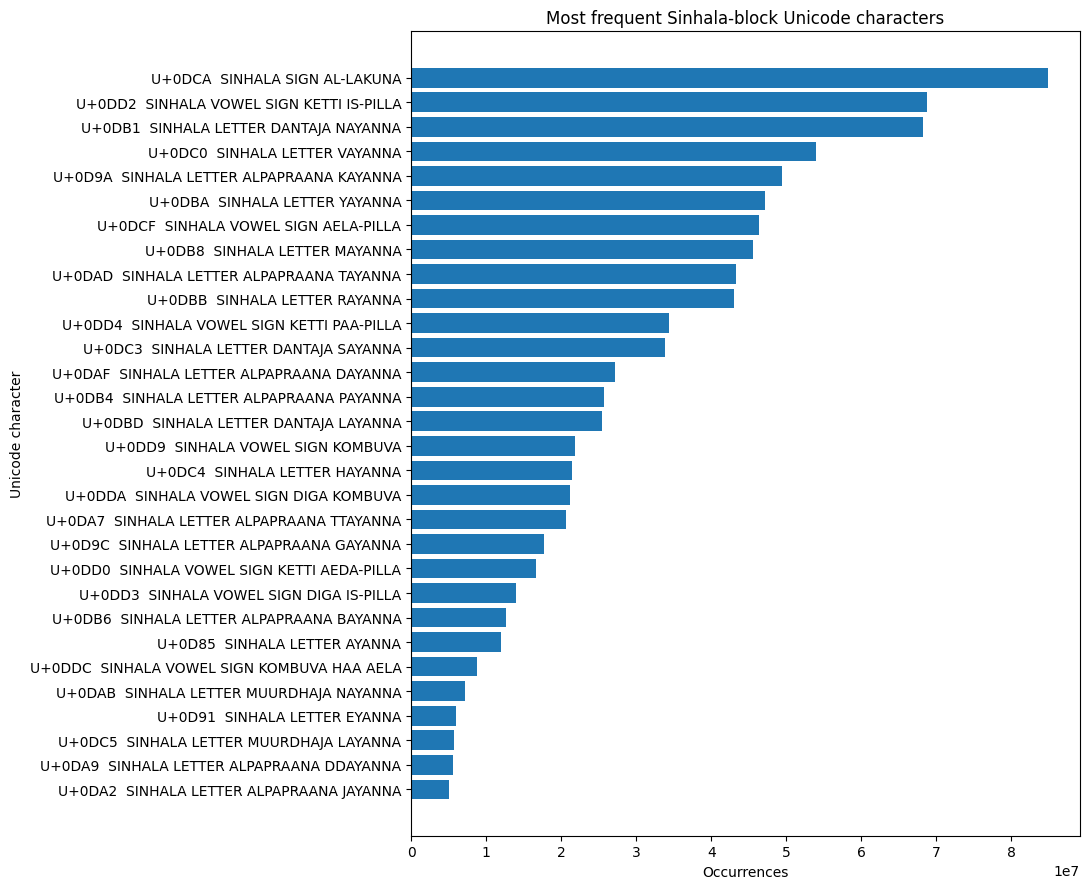

In [11]:
top_sinhala_chars = (
    char_df[
        char_df["is_sinhala_block"]
        & ~char_df["is_whitespace"]
    ]
    .sort_values("count", ascending=False)
    .head(50)
    .copy()
)

display(top_sinhala_chars)

plot_chars = top_sinhala_chars.head(30).sort_values("count")
labels = (
    plot_chars["codepoint"]
    + "  "
    + plot_chars["unicode_name"].str.slice(0, 35)
)

plt.figure(figsize=(11, 9))
plt.barh(labels, plot_chars["count"])
plt.xlabel("Occurrences")
plt.ylabel("Unicode character")
plt.title("Most frequent Sinhala-block Unicode characters")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_sinhala_characters.png", dpi=180)
plt.show()


## 11. Locate a Sinhala font and test glyph coverage

This checks whether each Unicode code point occurs in the font's character map (`cmap`). It measures glyph availability, not whether every complex Sinhala shaping sequence is typographically perfect.


In [12]:
import glob
from fontTools.ttLib import TTFont

font_candidates = sorted(
    glob.glob("/usr/share/fonts/**/*Sinhala*.ttf", recursive=True)
    + glob.glob("/usr/share/fonts/**/*sinhala*.ttf", recursive=True)
)

if not font_candidates:
    raise FileNotFoundError(
        "No Sinhala TTF font was found. Upload a Sinhala .ttf file to Colab "
        "and set FONT_PATH manually."
    )

preferred = [
    path for path in font_candidates
    if "NotoSansSinhala-Regular" in Path(path).name
]

FONT_PATH = preferred[0] if preferred else font_candidates[0]

print("Font candidates:")
for path in font_candidates[:20]:
    print(" -", path)
print("\nSelected font:", FONT_PATH)

ttfont = TTFont(FONT_PATH)
font_codepoints = set()

for cmap_table in ttfont["cmap"].tables:
    font_codepoints.update(cmap_table.cmap.keys())

coverage_df = char_df.copy()
coverage_df["font_has_codepoint"] = coverage_df["character"].map(
    lambda ch: ch.isspace() or ord(ch) in font_codepoints
)

nonspace_coverage = coverage_df[~coverage_df["is_whitespace"]].copy()
weighted_coverage = (
    nonspace_coverage.loc[
        nonspace_coverage["font_has_codepoint"], "count"
    ].sum()
    / nonspace_coverage["count"].sum()
)

missing_df = (
    nonspace_coverage[~nonspace_coverage["font_has_codepoint"]]
    .sort_values("count", ascending=False)
)
missing_df.to_csv(
    OUTPUT_DIR / "characters_missing_from_font.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"Frequency-weighted code-point coverage: {weighted_coverage:.6%}")
display(missing_df.head(30))


Font candidates:
 - /usr/share/fonts/truetype/noto/NotoSansSinhala-Bold.ttf
 - /usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf
 - /usr/share/fonts/truetype/noto/NotoSerifSinhala-Bold.ttf
 - /usr/share/fonts/truetype/noto/NotoSerifSinhala-Regular.ttf

Selected font: /usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf
Frequency-weighted code-point coverage: 98.466033%


,character,codepoint,unicode_name,unicode_category,count,is_sinhala_block,is_whitespace,font_has_codepoint
51,e,U+0065,LATIN SMALL LETTER E,Ll,1421130,False,False,False
55,a,U+0061,LATIN SMALL LETTER A,Ll,1144663,False,False,False
56,o,U+006F,LATIN SMALL LETTER O,Ll,1006618,False,False,False
57,i,U+0069,LATIN SMALL LETTER I,Ll,990731,False,False,False
58,t,U+0074,LATIN SMALL LETTER T,Ll,934738,False,False,False
60,r,U+0072,LATIN SMALL LETTER R,Ll,876837,False,False,False
62,n,U+006E,LATIN SMALL LETTER N,Ll,808139,False,False,False
64,s,U+0073,LATIN SMALL LETTER S,Ll,767933,False,False,False
69,l,U+006C,LATIN SMALL LETTER L,Ll,594914,False,False,False
78,c,U+0063,LATIN SMALL LETTER C,Ll,439467,False,False,False


## 12. Rendered pixel-width and fixed-canvas measurements

The next section measures a uniform sample of rows using:

- the selected Sinhala font
- a fixed font size
- a fixed image width
- word-aware wrapping
- grapheme-aware splitting when one word is too wide

For pixel-language-model work, keep font, font size, margins, antialiasing, line spacing, image width, and normalization policy fixed across the dataset.


In [13]:
from PIL import Image, ImageDraw, ImageFont, features

has_raqm = bool(features.check("raqm"))
layout_engine = (
    ImageFont.Layout.RAQM
    if has_raqm
    else ImageFont.Layout.BASIC
)

font = ImageFont.truetype(
    FONT_PATH,
    FONT_SIZE,
    layout_engine=layout_engine,
)

measurement_image = Image.new("L", (10, 10), 255)
measurement_draw = ImageDraw.Draw(measurement_image)

print("Pillow RAQM shaping available:", has_raqm)
if not has_raqm:
    print(
        "Warning: RAQM is unavailable. Pillow may not perform full complex-script "
        "shaping. Do not use the pixel measurements as final research results "
        "until a shaping-capable renderer is confirmed."
    )

def text_width_px(text):
    text = text or ""
    kwargs = {"font": font}
    if has_raqm:
        kwargs["language"] = "si"
    return float(measurement_draw.textlength(text, **kwargs))

def split_overwide_word(word, max_width):
    graphemes = GRAPHEME_RE.findall(word)
    pieces = []
    current = ""

    for grapheme in graphemes:
        candidate = current + grapheme
        if current and text_width_px(candidate) > max_width:
            pieces.append(current)
            current = grapheme
        else:
            current = candidate

    if current:
        pieces.append(current)

    return pieces or [""]

def wrap_for_canvas(text, max_width):
    # Treat all whitespace as separators for a consistent generated-image policy.
    words = NONSPACE_RE.findall(text or "")
    lines = []
    current_line = ""

    for word in words:
        word_pieces = (
            split_overwide_word(word, max_width)
            if text_width_px(word) > max_width
            else [word]
        )

        for piece in word_pieces:
            candidate = piece if not current_line else current_line + " " + piece

            if current_line and text_width_px(candidate) > max_width:
                lines.append(current_line)
                current_line = piece
            else:
                current_line = candidate

    if current_line:
        lines.append(current_line)

    return lines

line_height_px = max(
    1,
    int(round(FONT_SIZE * LINE_SPACING_MULTIPLIER)),
)
usable_width_px = CANVAS_WIDTH - (2 * HORIZONTAL_MARGIN)

pixel_rows = []

for sample in tqdm(pixel_text_sample):
    text = sample["text"]
    one_line_text = " ".join(text.split())
    one_line_width = text_width_px(one_line_text)
    wrapped_lines = wrap_for_canvas(text, usable_width_px)
    wrapped_line_count = len(wrapped_lines)

    estimated_height = (
        2 * VERTICAL_MARGIN
        + max(1, wrapped_line_count) * line_height_px
    )

    pixel_rows.append({
        "word_count": sample["word_count"],
        "grapheme_count": sample["grapheme_count"],
        "codepoint_count": sample["codepoint_count"],
        "src": sample["src"],
        "single_line_width_px": one_line_width,
        "wrapped_line_count": wrapped_line_count,
        "estimated_image_height_px": estimated_height,
        "fits_single_line": one_line_width <= usable_width_px,
        "pixels_per_grapheme": (
            one_line_width / sample["grapheme_count"]
            if sample["grapheme_count"] else 0.0
        ),
    })

pixel_df = pd.DataFrame(pixel_rows)
pixel_df.to_csv(PIXEL_METRICS_CSV, index=False)

display(pixel_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
print("Saved:", PIXEL_METRICS_CSV)


Pillow RAQM shaping available: True


  0%|          | 0/10000 [00:00<?, ?it/s]

,word_count,grapheme_count,codepoint_count,single_line_width_px,wrapped_line_count,estimated_image_height_px,pixels_per_grapheme
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.00000,10000.000000
mean,17.644600,78.967700,111.08550,2090.361105,2.74580,166.06940,26.528455
std,11.217882,52.262162,73.73323,1378.315216,1.56289,67.20429,1.444269
min,6.000000,18.000000,24.00000,374.906250,1.00000,91.00000,16.568257
10%,8.000000,33.000000,46.00000,876.064062,1.00000,91.00000,24.832865
25%,10.000000,43.000000,60.00000,1135.339844,2.00000,134.00000,25.813554
50%,14.000000,64.000000,90.00000,1691.171875,2.00000,134.00000,26.604915
75%,22.000000,99.000000,140.00000,2618.941406,3.00000,177.00000,27.402864
90%,32.000000,145.000000,204.00000,3823.985938,5.00000,263.00000,28.164298
95%,39.000000,177.000000,250.00000,4671.653125,6.00000,306.00000,28.679297


Saved: /content/sinllama_analysis/pixel_metrics_sample.csv


## 13. Pixel-metric visualizations


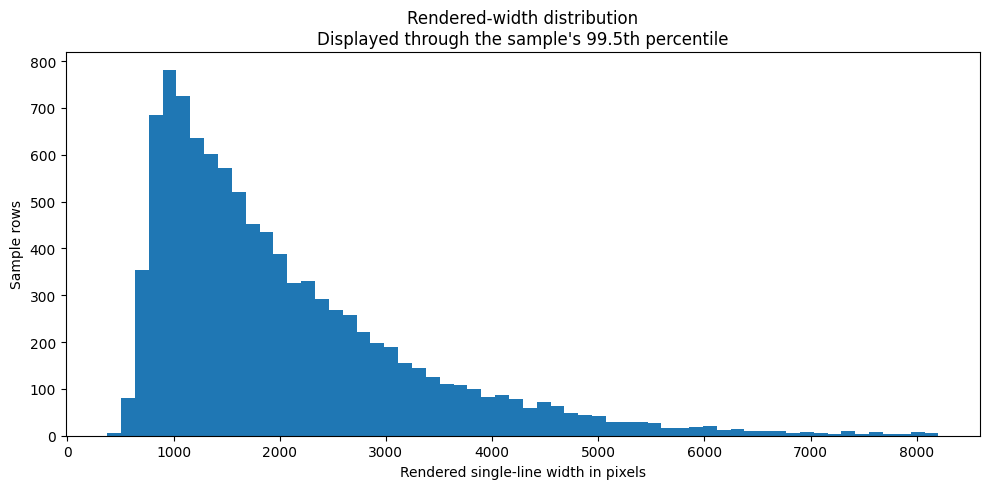

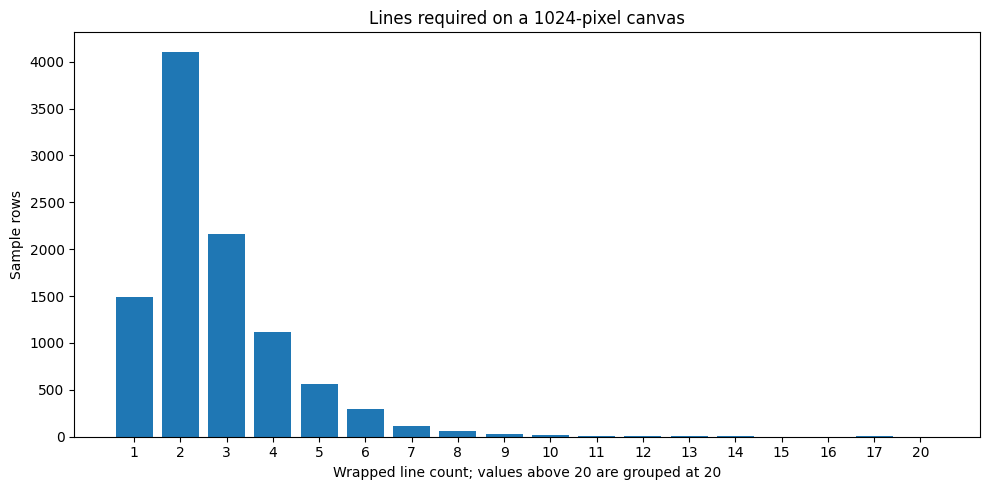

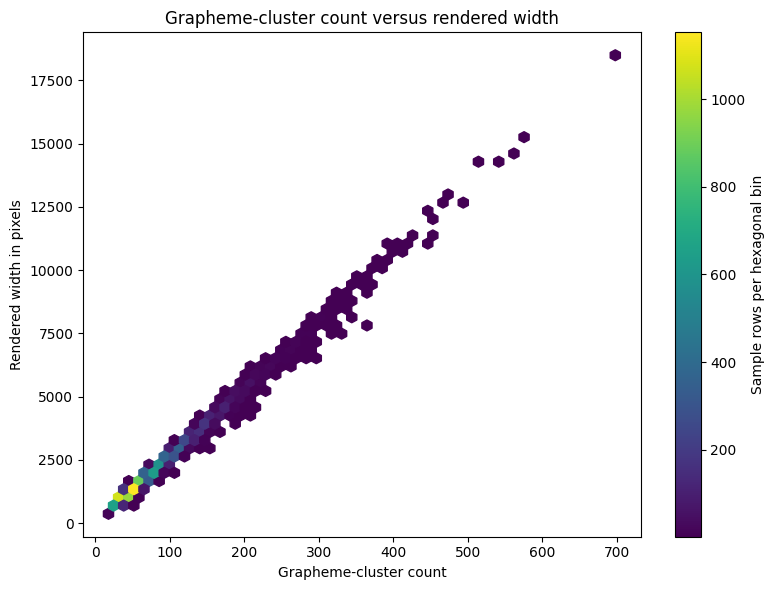

In [14]:
pixel_upper = pixel_df["single_line_width_px"].quantile(0.995)

plt.figure(figsize=(10, 5))
plt.hist(
    pixel_df.loc[
        pixel_df["single_line_width_px"] <= pixel_upper,
        "single_line_width_px",
    ],
    bins=60,
)
plt.xlabel("Rendered single-line width in pixels")
plt.ylabel("Sample rows")
plt.title(
    "Rendered-width distribution\n"
    "Displayed through the sample's 99.5th percentile"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rendered_width_distribution.png", dpi=180)
plt.show()

line_counts = (
    pixel_df["wrapped_line_count"]
    .clip(upper=20)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.bar(line_counts.index.astype(str), line_counts.values)
plt.xlabel("Wrapped line count; values above 20 are grouped at 20")
plt.ylabel("Sample rows")
plt.title(f"Lines required on a {CANVAS_WIDTH}-pixel canvas")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wrapped_line_count_distribution.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 6))
plt.hexbin(
    pixel_df["grapheme_count"],
    pixel_df["single_line_width_px"],
    gridsize=50,
    mincnt=1,
)
plt.xlabel("Grapheme-cluster count")
plt.ylabel("Rendered width in pixels")
plt.title("Grapheme-cluster count versus rendered width")
plt.colorbar(label="Sample rows per hexagonal bin")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "graphemes_vs_pixel_width.png", dpi=180)
plt.show()


## 14. Generate representative Sinhala font images

The notebook selects rows near several word-count quantiles from the pixel sample and renders each one as a separate image. These images help visually inspect shaping, wrapping, density, punctuation, and noise.


Quantile 10% | words=8 | graphemes=45 | saved=representative_q10.png


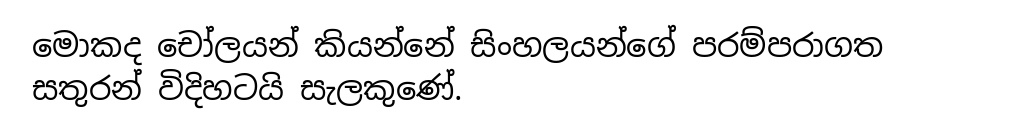

Quantile 50% | words=14 | graphemes=64 | saved=representative_q50.png


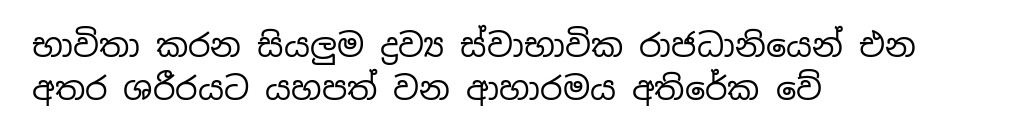

Quantile 90% | words=32 | graphemes=117 | saved=representative_q90.png


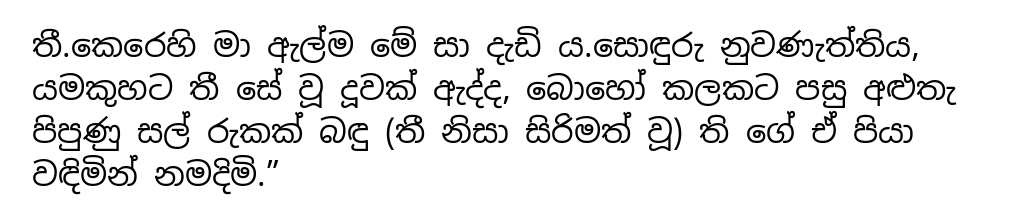

Quantile 99% | words=56 | graphemes=256 | saved=representative_q99.png


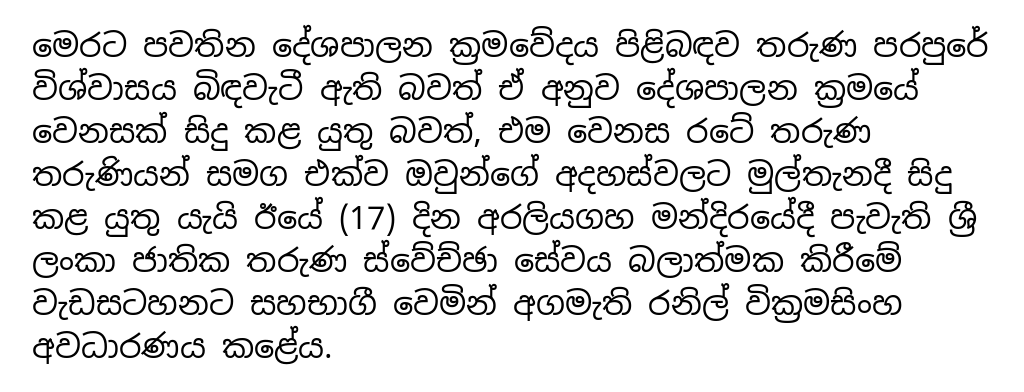

In [15]:
from IPython.display import display

def render_text_image(text, output_path):
    lines = wrap_for_canvas(text, usable_width_px)
    if not lines:
        lines = [""]

    image_height = (
        2 * VERTICAL_MARGIN
        + len(lines) * line_height_px
    )

    image = Image.new(
        "L",
        (CANVAS_WIDTH, image_height),
        255,
    )
    draw = ImageDraw.Draw(image)

    y = VERTICAL_MARGIN
    for line in lines:
        kwargs = {
            "font": font,
            "fill": 0,
        }
        if has_raqm:
            kwargs["language"] = "si"

        draw.text(
            (HORIZONTAL_MARGIN, y),
            line,
            **kwargs,
        )
        y += line_height_px

    image.save(output_path)
    return image

sample_text_df = pd.DataFrame(pixel_text_sample)
quantiles = [0.10, 0.50, 0.90, 0.99]
representative_rows = []

for quantile in quantiles:
    target = sample_text_df["word_count"].quantile(quantile)
    index = (
        sample_text_df["word_count"] - target
    ).abs().idxmin()
    representative_rows.append((quantile, sample_text_df.loc[index]))

for number, (quantile, row) in enumerate(representative_rows, start=1):
    output_path = OUTPUT_DIR / (
        f"representative_q{int(quantile * 100):02d}.png"
    )
    image = render_text_image(row["text"], output_path)

    print(
        f"Quantile {quantile:.0%} | "
        f"words={row['word_count']} | "
        f"graphemes={row['grapheme_count']} | "
        f"saved={output_path.name}"
    )
    display(image)


## 15. Recommended filtering analysis for a pixel-language model

Do not immediately delete rows. First report how many rows would be affected by each proposed rule.

The following cell evaluates example thresholds. Adjust them based on the model's fixed image dimensions and font size.


In [16]:
filter_report = pd.DataFrame({
    "condition": [
        "Empty row",
        "Fewer than 3 words",
        "More than 256 words",
        "Sinhala ratio below 80%",
        "Contains a control character",
        "Requires more than 8 wrapped lines",
        "Rendered width above sample p99",
    ],
    "affected_rows_or_sample_rows": [
        int(
            con.execute(f'''
                SELECT COUNT(*)
                FROM read_parquet('{METRICS_PARQUET}')
                WHERE word_count = 0
            ''').fetchone()[0]
        ),
        int(
            con.execute(f'''
                SELECT COUNT(*)
                FROM read_parquet('{METRICS_PARQUET}')
                WHERE word_count < 3
            ''').fetchone()[0]
        ),
        int(
            con.execute(f'''
                SELECT COUNT(*)
                FROM read_parquet('{METRICS_PARQUET}')
                WHERE word_count > 256
            ''').fetchone()[0]
        ),
        int(
            con.execute(f'''
                SELECT COUNT(*)
                FROM read_parquet('{METRICS_PARQUET}')
                WHERE sinhala_ratio_nonspace < 0.80
            ''').fetchone()[0]
        ),
        int(
            con.execute(f'''
                SELECT COUNT(*)
                FROM read_parquet('{METRICS_PARQUET}')
                WHERE control_count > 0
            ''').fetchone()[0]
        ),
        int((pixel_df["wrapped_line_count"] > 8).sum()),
        int(
            (
                pixel_df["single_line_width_px"]
                > pixel_df["single_line_width_px"].quantile(0.99)
            ).sum()
        ),
    ],
    "denominator": [
        rows_seen,
        rows_seen,
        rows_seen,
        rows_seen,
        rows_seen,
        len(pixel_df),
        len(pixel_df),
    ],
})

filter_report["percentage"] = (
    100
    * filter_report["affected_rows_or_sample_rows"]
    / filter_report["denominator"]
)
filter_report.to_csv(OUTPUT_DIR / "candidate_filter_report.csv", index=False)
display(filter_report)


,condition,affected_rows_or_sample_rows,denominator,percentage
0,Empty row,0,10730154,0.000000
1,Fewer than 3 words,0,10730154,0.000000
2,More than 256 words,417,10730154,0.003886
3,Sinhala ratio below 80%,575820,10730154,5.366372
4,Contains a control character,5113427,10730154,47.654740
5,Requires more than 8 wrapped lines,85,10000,0.850000
6,Rendered width above sample p99,100,10000,1.000000


## 16. Package all outputs

The ZIP contains the summary tables, Parquet metrics, font-coverage report, charts, and representative text images.


In [17]:
import shutil

ZIP_BASE = "/content/sinllama_analysis_results"
zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Created:", zip_path)

# To download in Colab, run:
# from google.colab import files
# files.download(zip_path)


Created: /content/sinllama_analysis_results.zip


# How to interpret the main outputs

- **`summary_statistics.csv`**: central tendency, spread, and upper-tail statistics.
- **`word_count_distribution.png`**: ordinary whitespace-based text length.
- **`grapheme_distribution.png`**: closer to visible Sinhala units than code-point count.
- **`rendered_width_distribution.png`**: how wide rows become under one fixed font configuration.
- **`wrapped_line_count_distribution.png`**: image-packing pressure for a fixed canvas.
- **`graphemes_vs_pixel_width.png`**: whether visual width is predictable from grapheme count.
- **`characters_missing_from_font.csv`**: corpus characters not represented in the selected font's cmap.
- **`representative_*.png`**: direct visual inspection at several length quantiles.
- **`candidate_filter_report.csv`**: impact of possible cleaning rules before applying them.

## Research cautions

1. Record the exact font file and font license.
2. Record font size, canvas size, margins, line spacing, antialiasing, text direction, and normalization policy.
3. Confirm RAQM/HarfBuzz shaping before generating the final training images.
4. Do not resize long text images non-uniformly; this changes glyph shapes.
5. Prefer wrapping or segmenting into fixed visual lines rather than shrinking every sentence.
6. Split train/validation/test before image augmentation to prevent leakage from duplicate or near-duplicate text.
7. Report both text-level and image-level distributions.


In [18]:
from pathlib import Path
import shutil

# Existing output folder created by the analysis notebook
SOURCE_DIR = Path("/content/sinllama_analysis")

# GitHub-ready project folder
PROJECT_DIR = Path("/content/sinllama-dataset-visual-analysis")

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"
FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"
SAMPLES_DIR = PROJECT_DIR / "samples"

# Create folders
for folder in [
    NOTEBOOKS_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    SAMPLES_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folder structure created.")

Folder structure created.


In [19]:
# Graphs to place inside figures/
figure_files = [
    "word_count_distribution.png",
    "codepoint_distribution.png",
    "grapheme_distribution.png",
    "rendered_width_distribution.png",
    "wrapped_line_count_distribution.png",
    "graphemes_vs_pixel_width.png",
    "word_vs_grapheme_hexbin.png",
    "top_sinhala_characters.png",
    "source_distribution.png",
]

# CSV reports to place inside reports/
report_files = [
    "summary_statistics.csv",
    "character_frequency.csv",
    "characters_missing_from_font.csv",
    "pixel_metrics_sample.csv",
    "candidate_filter_report.csv",
    "source_distribution.csv",
    "longest_examples.csv",
]

# Copy figures
for filename in figure_files:
    source_file = SOURCE_DIR / filename

    if source_file.exists():
        shutil.copy2(source_file, FIGURES_DIR / filename)
        print("Copied figure:", filename)
    else:
        print("Figure not found:", filename)

# Copy reports
for filename in report_files:
    source_file = SOURCE_DIR / filename

    if source_file.exists():

        shutil.copy2(source_file, REPORTS_DIR / filename)
        print("Copied report:", filename)
    else:
        print("Report not found:", filename)

# Copy representative Sinhala text images
for source_file in SOURCE_DIR.glob("representative_*.png"):
    shutil.copy2(source_file, SAMPLES_DIR / source_file.name)
    print("Copied sample:", source_file.name)

Copied figure: word_count_distribution.png
Copied figure: codepoint_distribution.png
Copied figure: grapheme_distribution.png
Copied figure: rendered_width_distribution.png
Copied figure: wrapped_line_count_distribution.png
Copied figure: graphemes_vs_pixel_width.png
Copied figure: word_vs_grapheme_hexbin.png
Copied figure: top_sinhala_characters.png
Copied figure: source_distribution.png
Copied report: summary_statistics.csv
Copied report: character_frequency.csv
Copied report: characters_missing_from_font.csv
Copied report: pixel_metrics_sample.csv
Copied report: candidate_filter_report.csv
Copied report: source_distribution.csv
Copied report: longest_examples.csv
Copied sample: representative_q50.png
Copied sample: representative_q10.png
Copied sample: representative_q99.png
Copied sample: representative_q90.png


In [20]:
for path in sorted(PROJECT_DIR.rglob("*")):
    relative_path = path.relative_to(PROJECT_DIR)

    if path.is_dir():
        print(f"[Folder] {relative_path}/")
    else:
        print(f"[File]   {relative_path}")

[Folder] figures/
[File]   figures/codepoint_distribution.png
[File]   figures/grapheme_distribution.png
[File]   figures/graphemes_vs_pixel_width.png
[File]   figures/rendered_width_distribution.png
[File]   figures/source_distribution.png
[File]   figures/top_sinhala_characters.png
[File]   figures/word_count_distribution.png
[File]   figures/word_vs_grapheme_hexbin.png
[File]   figures/wrapped_line_count_distribution.png
[Folder] notebooks/
[Folder] reports/
[File]   reports/candidate_filter_report.csv
[File]   reports/character_frequency.csv
[File]   reports/characters_missing_from_font.csv
[File]   reports/longest_examples.csv
[File]   reports/pixel_metrics_sample.csv
[File]   reports/source_distribution.csv
[File]   reports/summary_statistics.csv
[Folder] samples/
[File]   samples/representative_q10.png
[File]   samples/representative_q50.png
[File]   samples/representative_q90.png
[File]   samples/representative_q99.png


In [21]:
from google.colab import files

zip_file = shutil.make_archive(
    "/content/sinllama-dataset-visual-analysis",
    "zip",
    root_dir=PROJECT_DIR,
)

print("Created:", zip_file)
files.download(zip_file)

Created: /content/sinllama-dataset-visual-analysis.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>